# Milestone 2 — photo check of the 40 biggest losses

The loss list is the one from `m2_masked.ipynb` section 7: end-minus-start on the masked table,
25% minimum land, losses ranked on their own. `m2_top_photo_check.ipynb` already looked at ranks
1-8 (they were ranks 2, 3, 5, 6, 8, 9, 10 and 11 of that notebook's mixed list). This notebook looks
at ranks 9-40, so that every hex on the list has been seen before any of it is quoted.

1. **Water the mask missed**, for ranks 9-40: the share of each hex's remaining land that read as
   open water each year. The same test as the earlier photo check.
2. **The photos**: eight dry seasons of each hex, true colour, the hex in yellow, masked OSM water
   in red, kept wetland in magenta. The number under each year is the hex's normalised greenness.
3. **A verdict for every one of the 40**, written to `results/m2_loss_verdicts.csv`.

Each verdict answers one question: did green cover on dry land really go? The categories:

- **real loss**: vegetation cleared or built over, visible in the photos;
- **real loss, wetland**: the same, where the ground cleared was mapped wetland;
- **lake works**: vegetation removed as part of a lake project, not development;
- **doubtful**: the photos don't show a clear cause (crop cycles, a lake edge, shadow);
- **artefact**: the number comes from something other than land change.

**Needs Earth Engine.** Run with `EE_PROJECT` set.

In [1]:
import io
import json
import os
import socket
import urllib.request
from pathlib import Path

import ee
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box as shapely_box

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)

COLLECTION = "COPERNICUS/S2_SR_HARMONIZED"
METRIC = "EPSG:32643"
RGB_MAX = 3000
HEX_EDGE, MASK_EDGE, WETLAND_EDGE = "#ffe600", "#ff2d2d", "#ff4dff"
LAND_CUTOFF = 0.25
CLEAN_CUTOFF = 0.90
TOP = 40
CHECKED = 8

old = pd.read_csv("results/m2_hex_table.csv")
table = pd.read_csv("results/m2_hex_table_masked.csv")
green = table.pivot(index="h3", columns="year", values="green")
YEARS = list(green.columns)
norm = green.sub(green.mean(axis=0), axis=1)
change = norm[YEARS[-1]] - norm[YEARS[0]]
land = table.groupby("h3").n_pixels.median() / old.groupby("h3").n_pixels.median()
losses = change[land.reindex(change.index) >= LAND_CUTOFF].nsmallest(TOP).index
rank = pd.Series(range(1, TOP + 1), index=losses)

osm = gpd.read_file("data/osm_water.geojson")
masked = osm[osm["class"] != "wetland"]
wetland = osm[osm["class"] == "wetland"]
grid = gpd.read_file("data/hex_grid.geojson").to_crs(METRIC).set_index("h3")
pieces = gpd.overlay(grid.loc[losses].reset_index()[["h3", "geometry"]], osm.to_crs(METRIC)[["geometry"]])
clean_land = 1 - (pieces.dissolve(by="h3").area / grid.loc[losses].area).reindex(losses).fillna(0)

cache = json.loads(Path("data/place_names.json").read_text())


def locality(hx):
    lat, lng = h3.cell_to_latlng(hx)
    addr = cache[f"reverse?format=json&lat={lat:.5f}&lon={lng:.5f}&zoom=14"].get("address", {})
    return next((addr[k] for k in ("suburb", "neighbourhood", "village", "town", "city_district", "hamlet")
                 if k in addr), "")


assert list(losses[:CHECKED]) == ["88618921a3fffff", "8861892c69fffff", "88618921b5fffff", "8860169685fffff",
                                  "8861892c61fffff", "886016968bfffff", "8860169681fffff", "88618921a1fffff"]
todo = losses[CHECKED:]

socket.setdefaulttimeout(120)
ee.Initialize(project=os.environ["EE_PROJECT"])
ee.data.setDeadline(120_000)


def retry(fetch, tries=4):
    for attempt in range(tries):
        try:
            return fetch()
        except Exception as exc:
            if attempt == tries - 1:
                raise
            print(f"  retrying after {type(exc).__name__}")


def hex_geom(hx):
    return ee.Geometry.Polygon([[[lng, lat] for lat, lng in h3.cell_to_boundary(hx)]])


def composite(year, region):
    return (ee.ImageCollection(COLLECTION).filterBounds(region)
            .filterDate(f"{year}-02-01", f"{year}-03-31").median())


def to_fc(frame):
    return ee.FeatureCollection([ee.Feature(ee.Geometry(g.__geo_interface__)) for g in frame.geometry])


def near(frame, bounds):
    return frame[frame.intersects(shapely_box(*bounds))]


def land_mask(bounds):
    lakes = near(masked, bounds)
    return ee.Image.constant(1).paint(to_fc(lakes), 0) if len(lakes) else ee.Image.constant(1)


def outline(frame, colour, width=1):
    if frame.empty:
        return None
    return ee.Image().byte().paint(to_fc(frame), 1, width).selfMask().visualize(palette=[colour])


def thumb(image, region, px=230):
    def fetch():
        url = image.getThumbURL({"region": region, "dimensions": px, "format": "jpg"})
        return plt.imread(io.BytesIO(urllib.request.urlopen(url).read()), format="jpg")
    return retry(fetch)


print(f"{TOP} biggest losses; ranks 1-{CHECKED} checked 2026-09-23, ranks {CHECKED + 1}-{TOP} here; "
      "Earth Engine ready")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


40 biggest losses; ranks 1-8 checked 2026-09-23, ranks 9-40 here; Earth Engine ready


---
## 1 — Water the mask missed

Of the pixels the mask kept as land, the share that read as open water (wetness index above zero),
per year. A hex at 0-1% every year is measured on dry land. One that jumps in some years has lake
inside its "land", and that alone moves its greenness.

In [2]:
leak = {}
for hx in todo:
    lat, lng = h3.cell_to_latlng(hx)
    mask = land_mask((lng - 0.01, lat - 0.01, lng + 0.01, lat + 0.01))
    geom = hex_geom(hx)
    shares = ee.List([composite(y, geom).normalizedDifference(["B3", "B11"]).gt(0).updateMask(mask)
                      .reduceRegion(ee.Reducer.mean(), geom, 10).values().get(0) for y in YEARS])
    leak[hx] = retry(shares.getInfo)

leak = pd.DataFrame(leak, index=YEARS).T
view = leak.map(lambda v: "" if v is None else f"{v:.0%}")
view.insert(0, "rank", rank[todo])
view.insert(1, "change", change[todo].round(3))
view.insert(2, "clean land", clean_land[todo].map("{:.0%}".format))
print("share of each hex's remaining land that read as open water, by year")
print(view.to_string())
print(f"\nhexes whose land read >5% water in any year: {(leak.max(axis=1) > 0.05).sum()} of {len(todo)}")

share of each hex's remaining land that read as open water, by year
                 rank  change clean land 2019 2020 2021 2022 2023 2024 2025 2026
886189208dfffff     9  -0.165        84%   0%   0%   0%   0%   0%   0%   1%   1%
88618920edfffff    10  -0.163        78%   1%   1%   0%   0%   0%   0%   0%   0%
8861892031fffff    11  -0.156        61%   0%   0%   0%   0%   0%   0%   0%   0%
8860169683fffff    12  -0.154       100%   0%   0%   0%   0%   0%   0%   0%   0%
88618920e5fffff    13  -0.148        94%   0%   0%   1%   0%   1%   1%   1%   1%
886016963bfffff    14  -0.147        96%   0%   0%   0%   0%   0%   0%   0%   0%
8861892f17fffff    15  -0.145        61%   0%   0%   0%   0%   0%   0%   0%   0%
88601696d5fffff    16  -0.145       100%   0%   0%   0%   0%   0%   0%   0%   0%
8861892a35fffff    17  -0.144       100%   0%   0%   0%   0%   0%   0%   0%   0%
88618921c5fffff    18  -0.144        97%   0%   0%   0%   0%   2%   0%   0%   0%
886189206bfffff    19  -0.140       100% 

---
## 2 — The photos

Ranks 9-40, one row each. Yellow is the hex, red is masked OSM water, magenta is kept wetland. The
number under each year is the normalised greenness the ranking uses; the change is the last minus
the first.

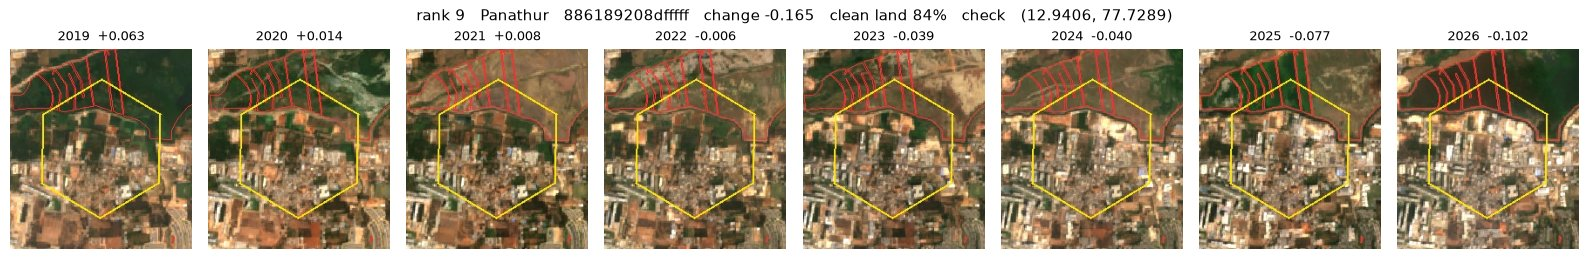

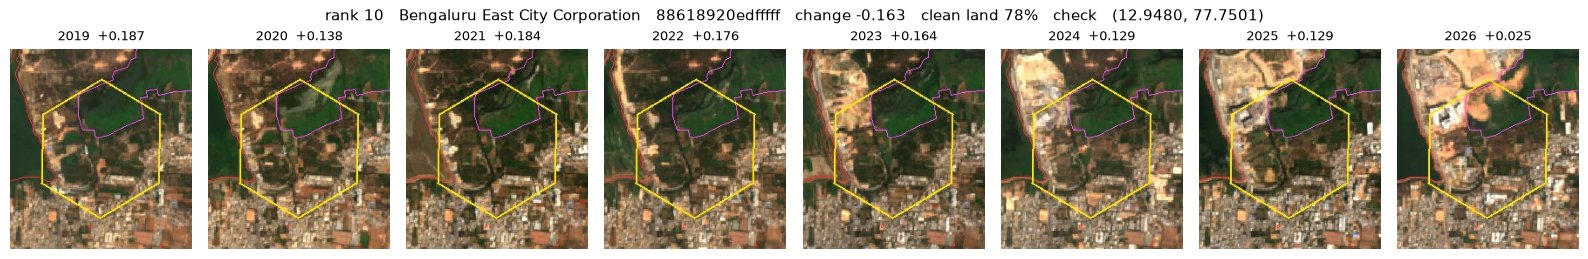

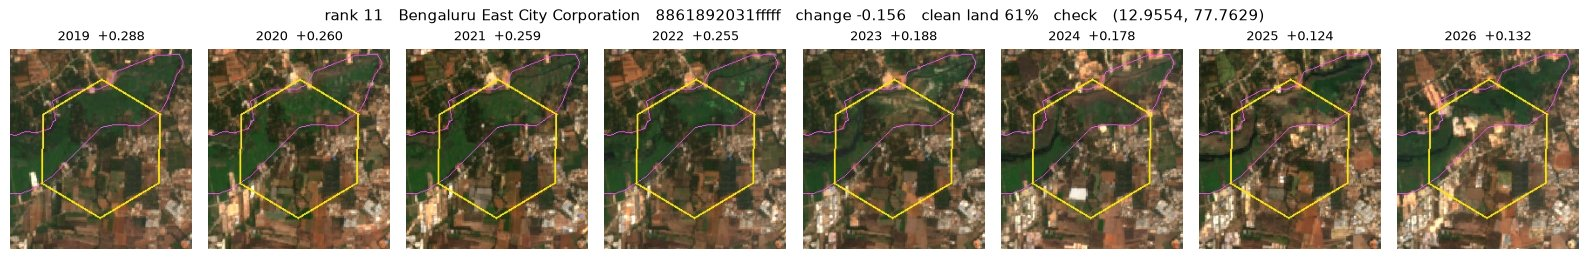

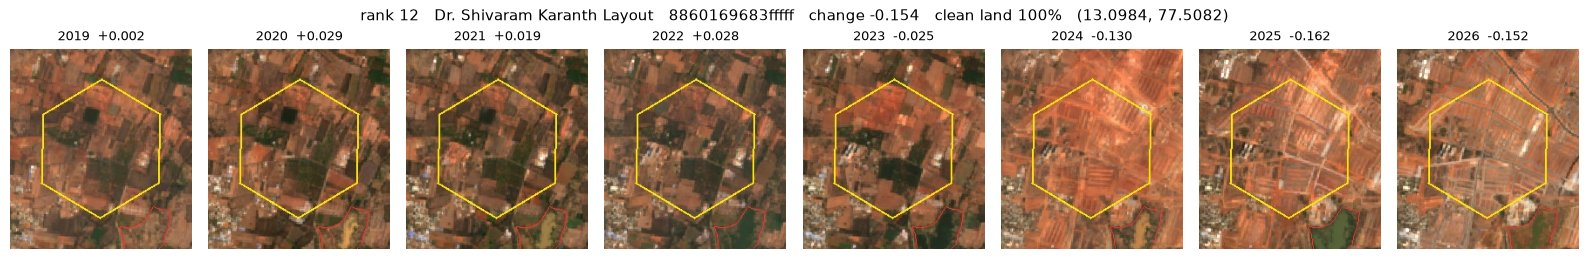

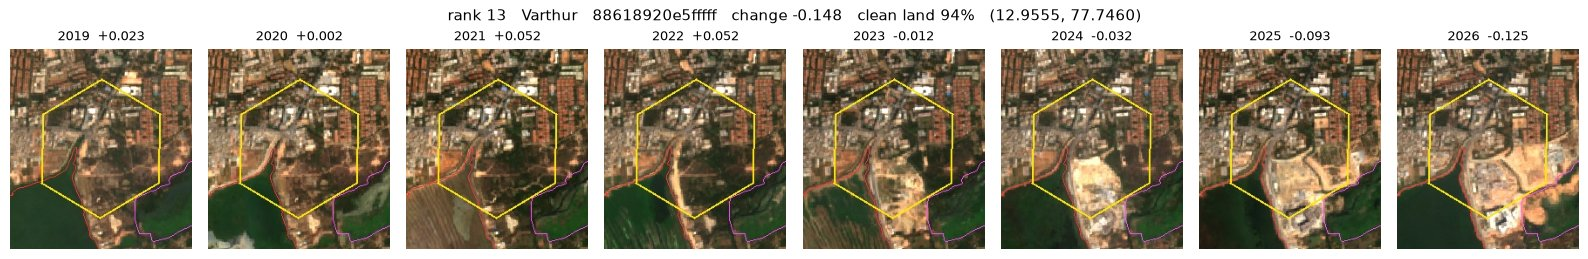

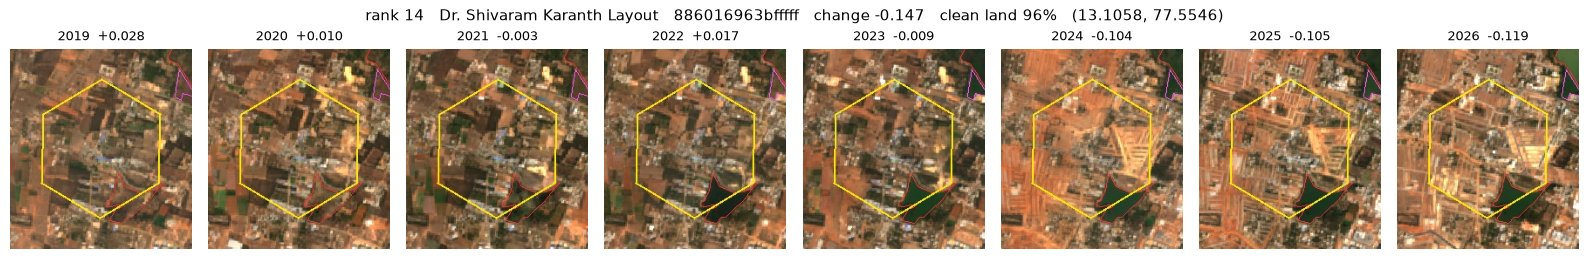

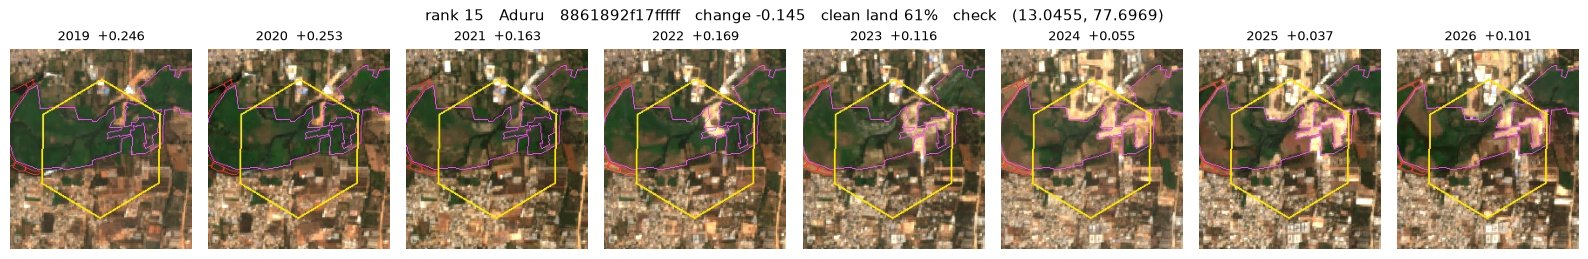

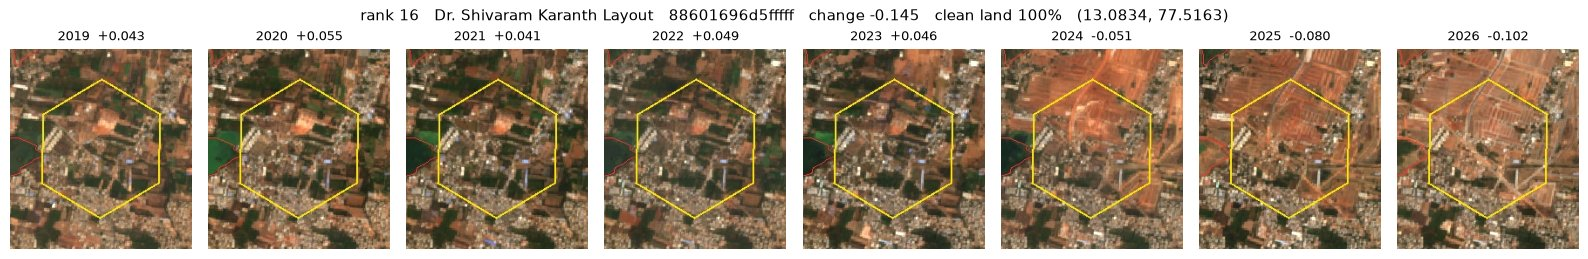

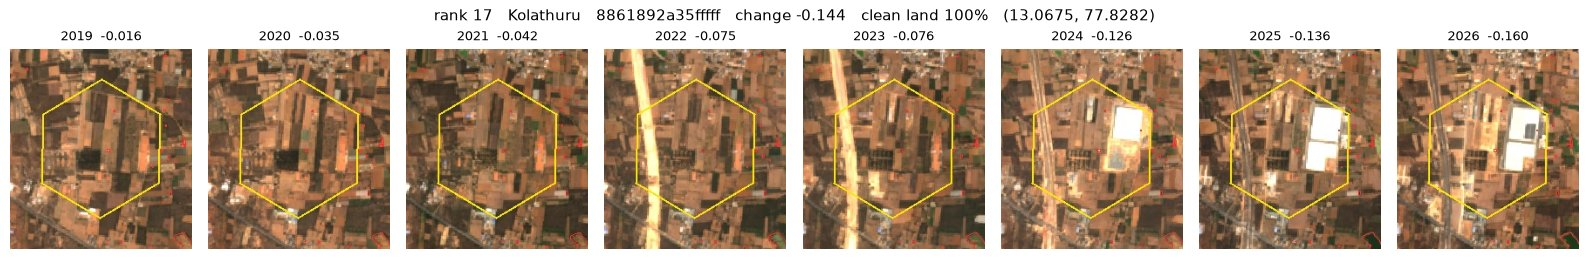

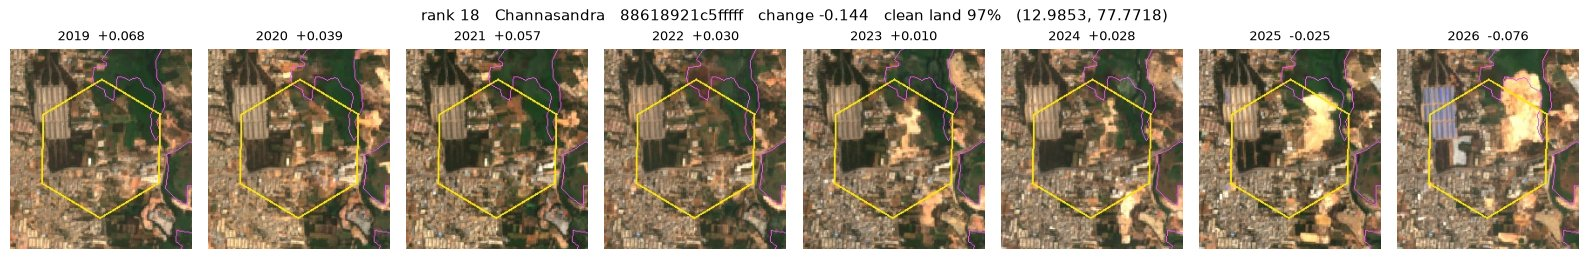

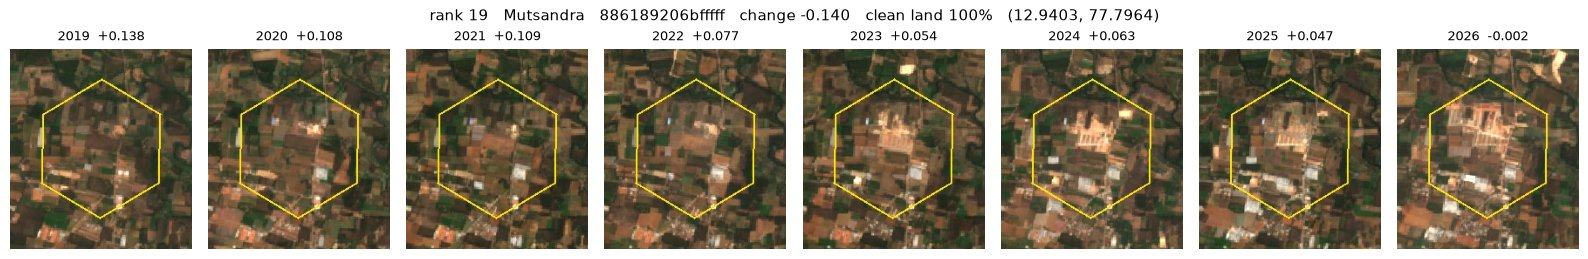

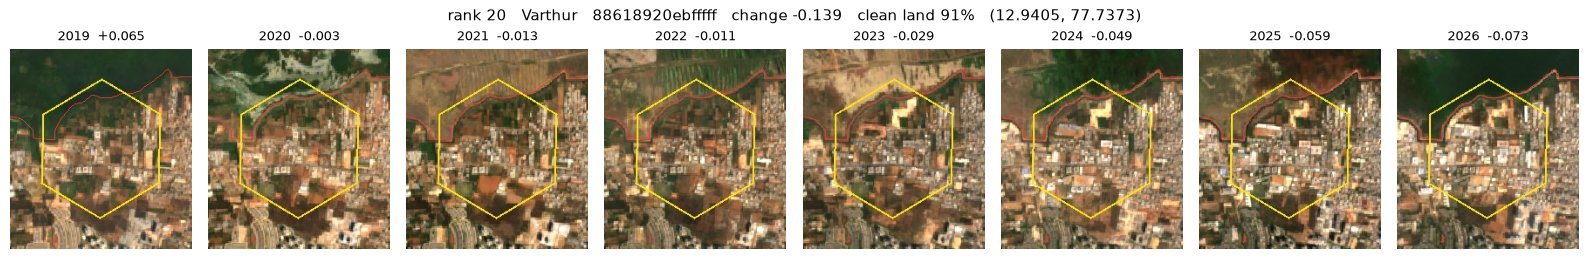

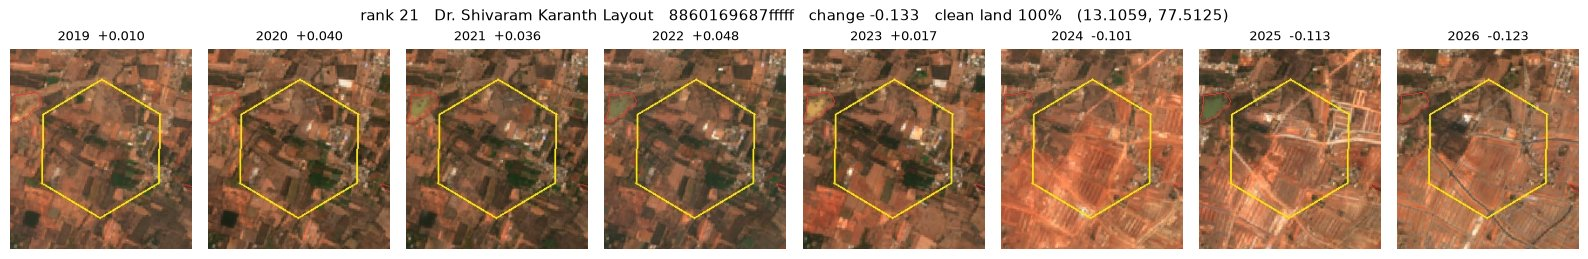

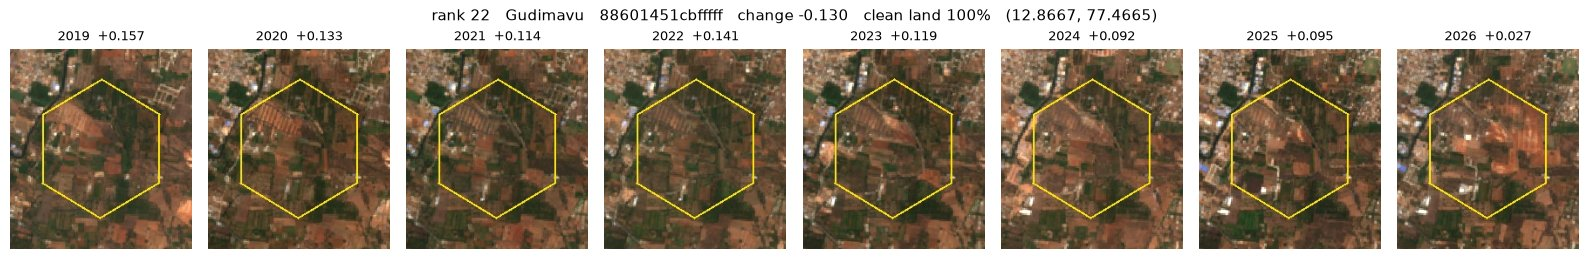

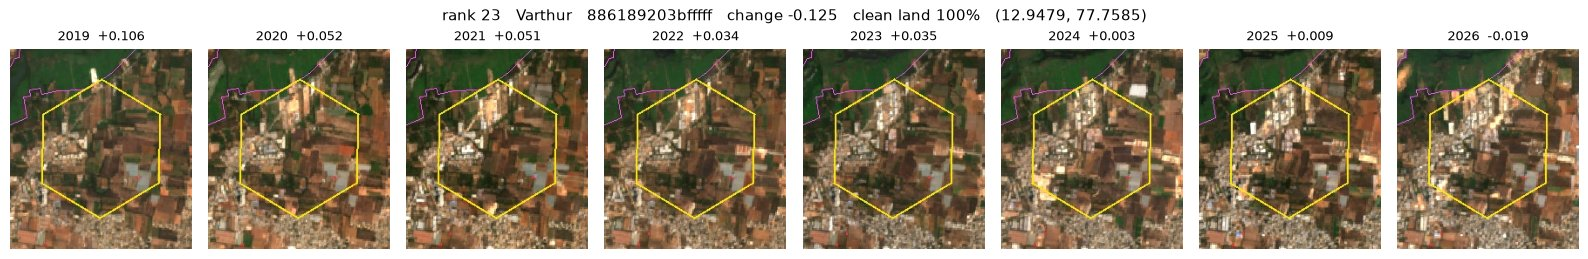

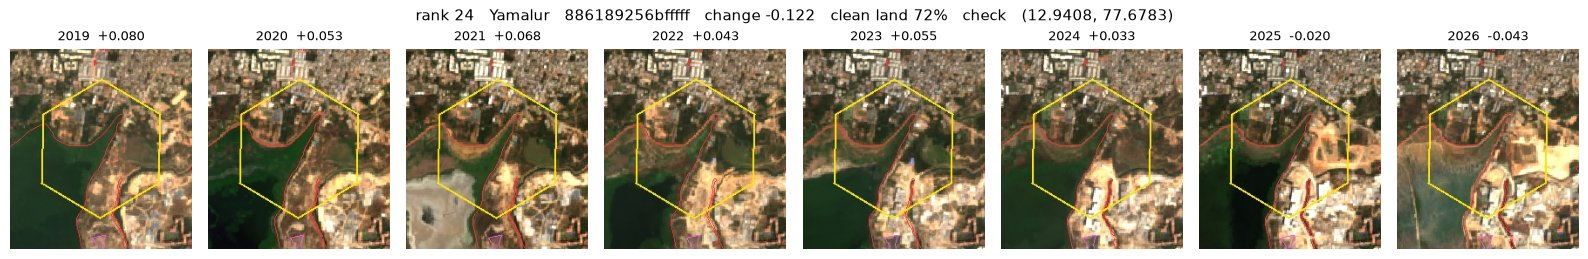

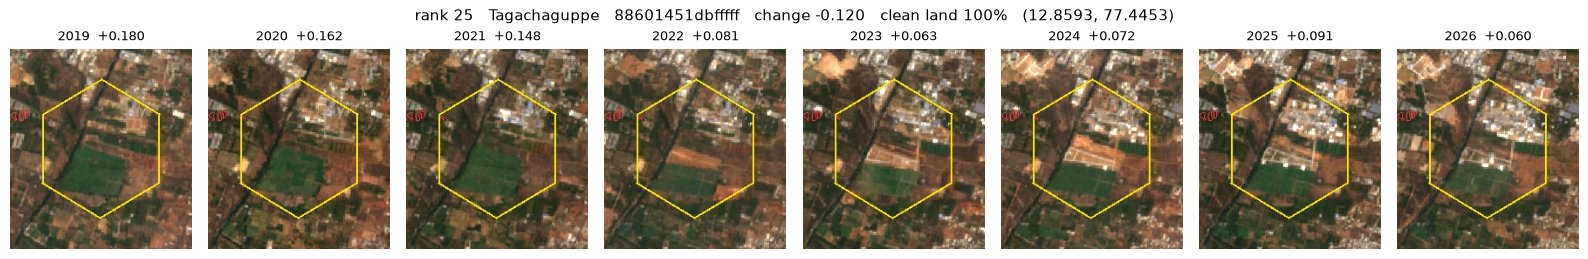

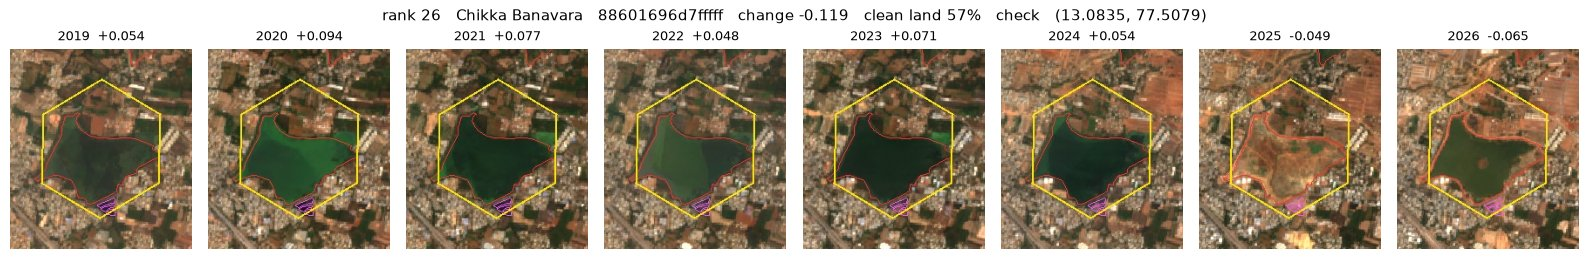

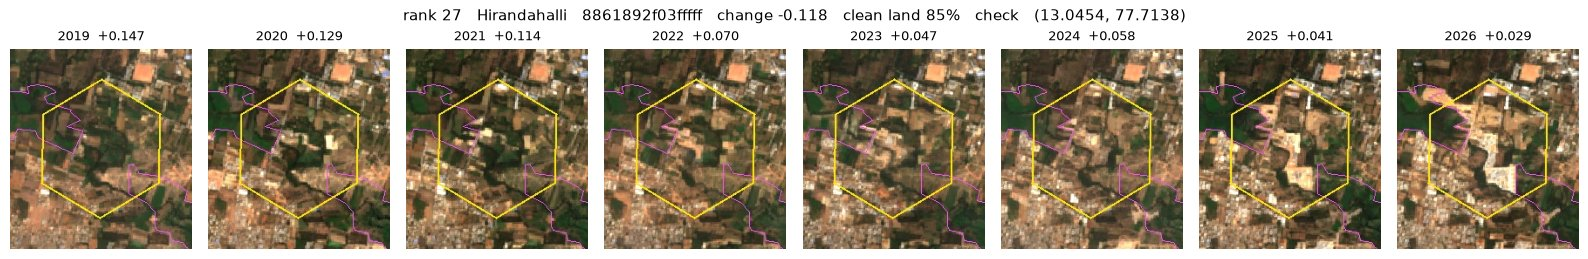

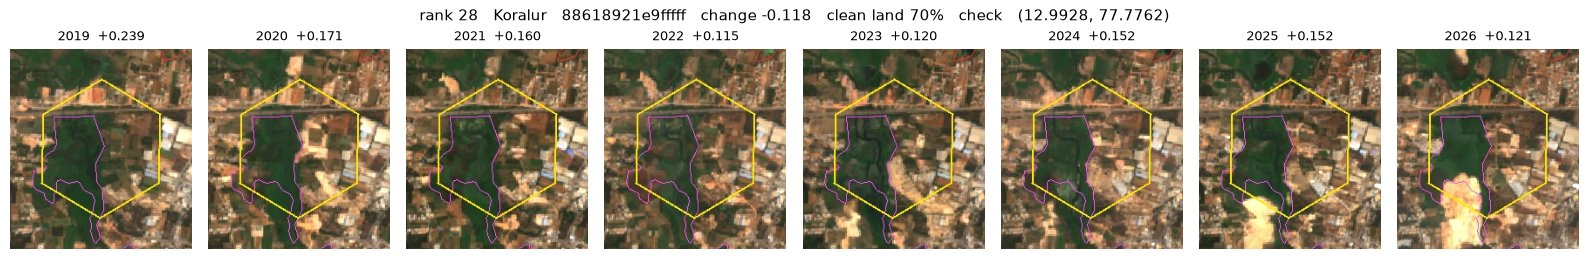

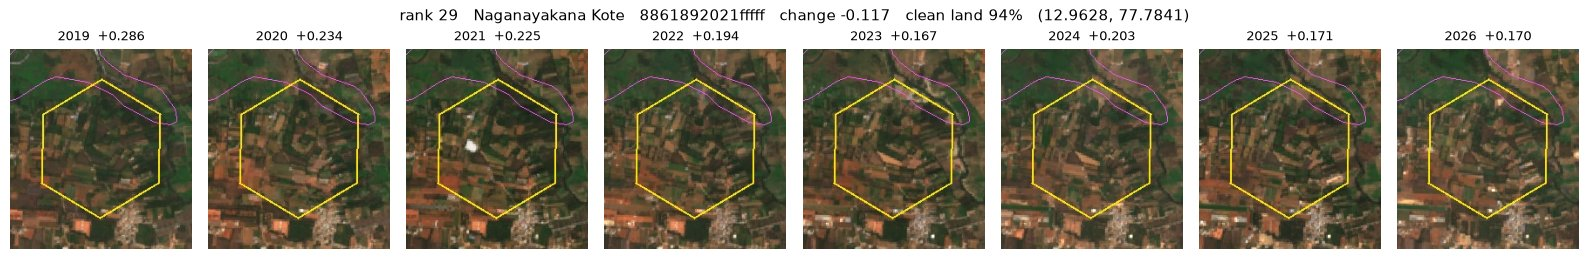

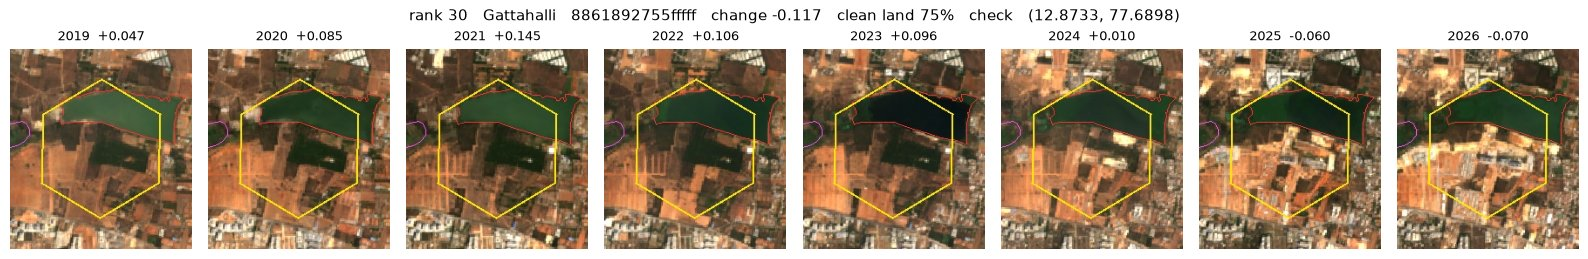

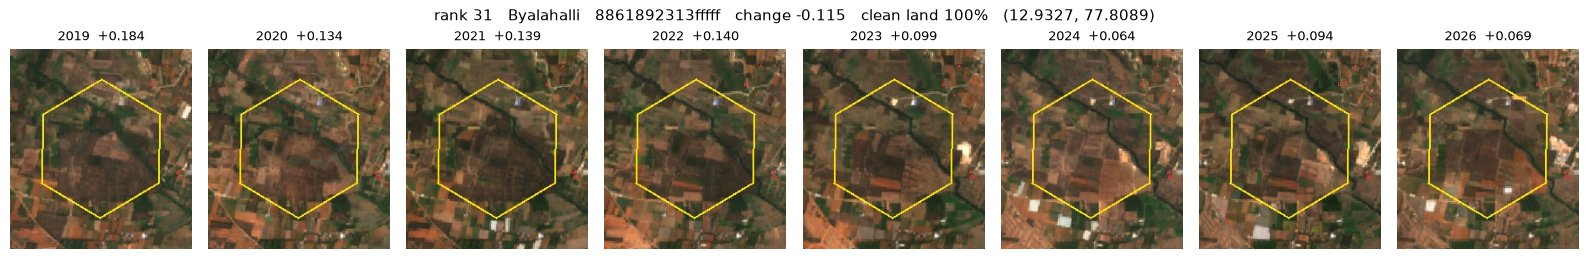

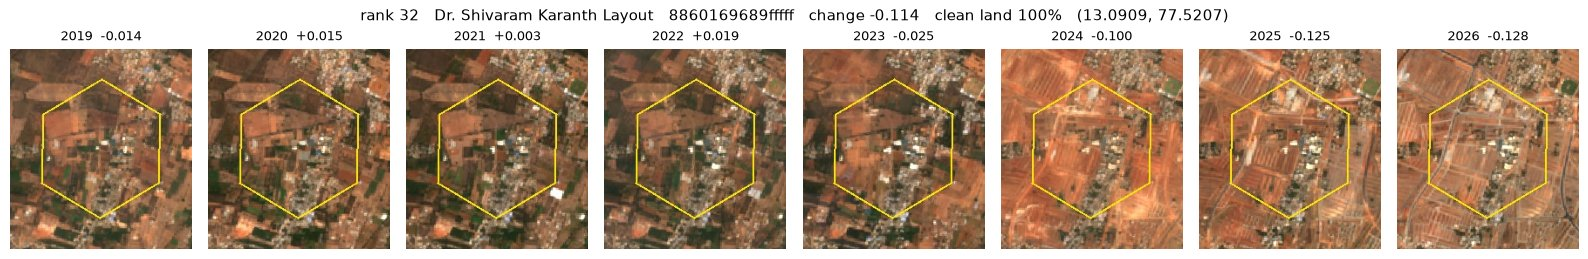

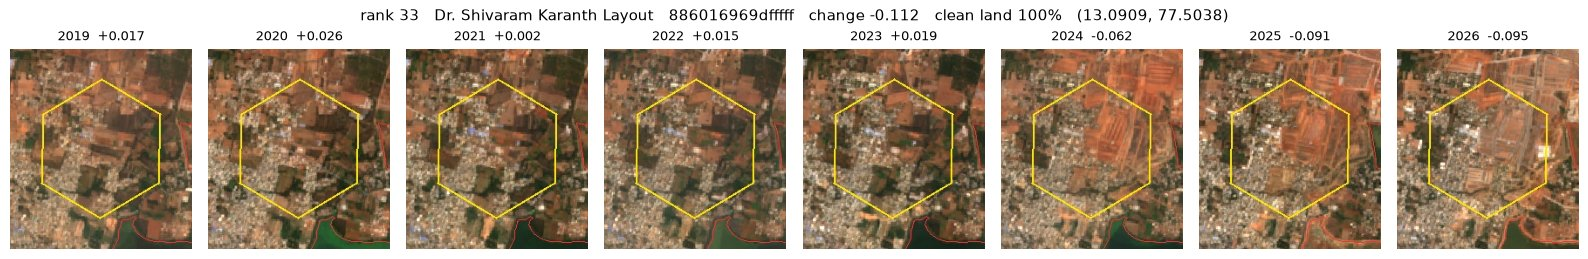

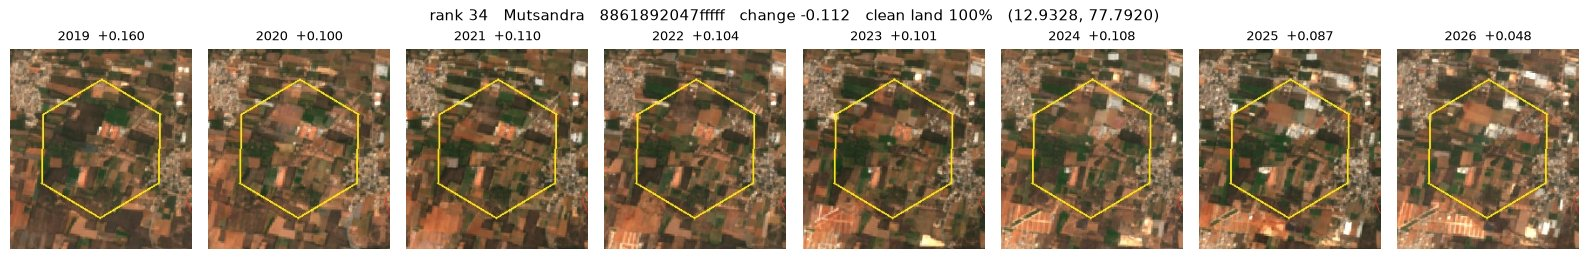

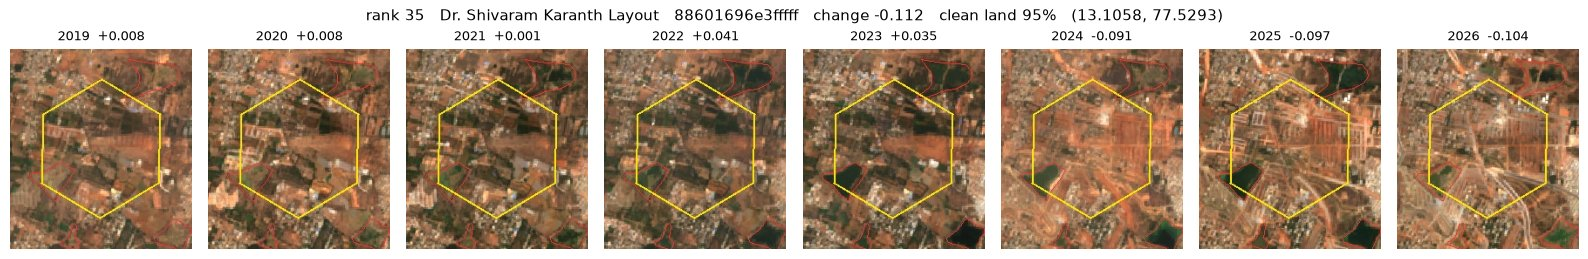

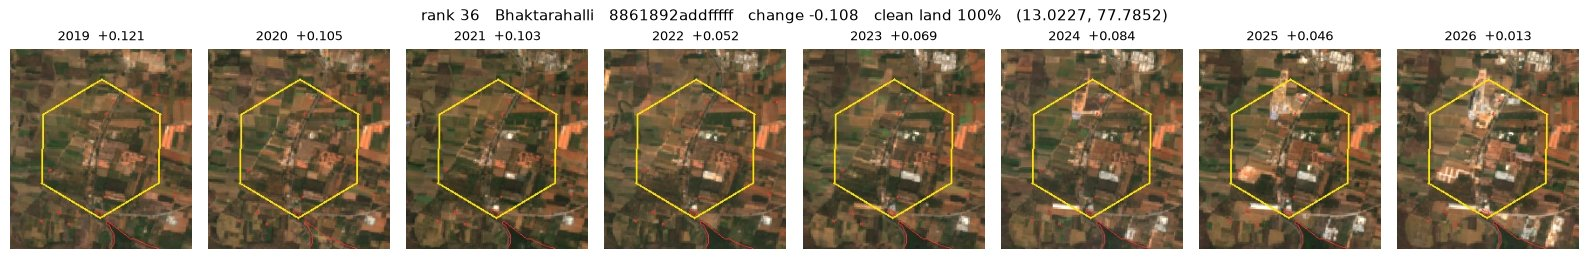

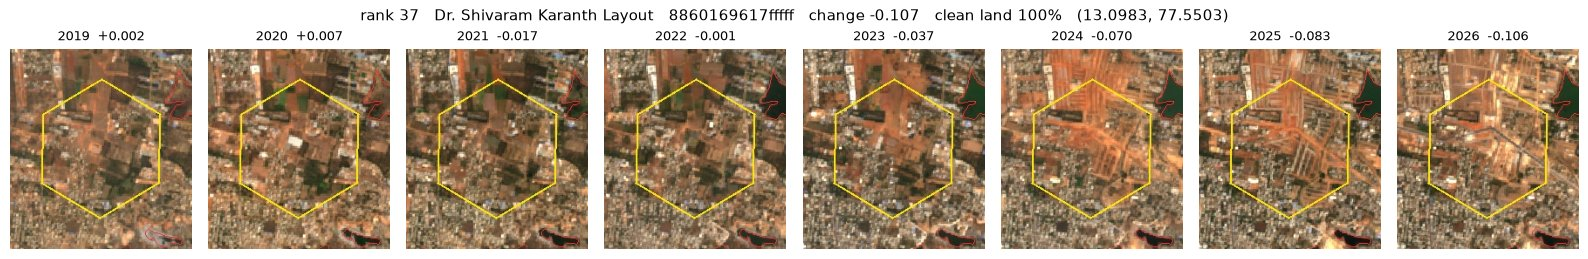

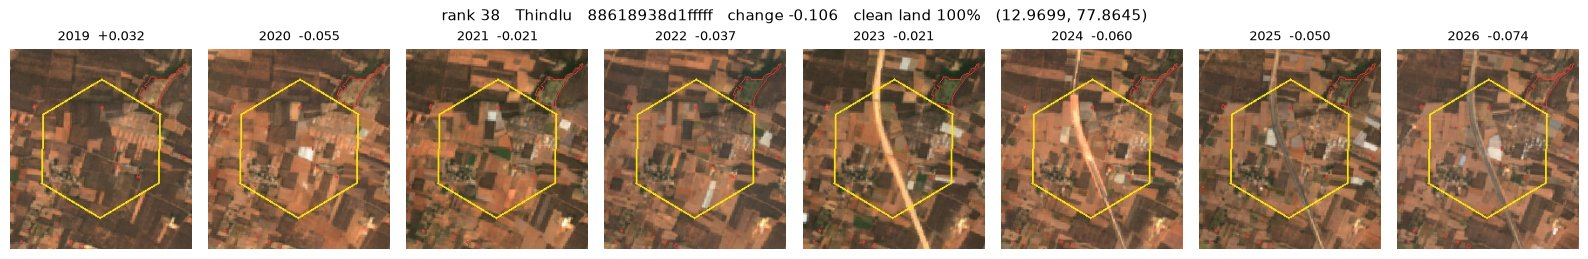

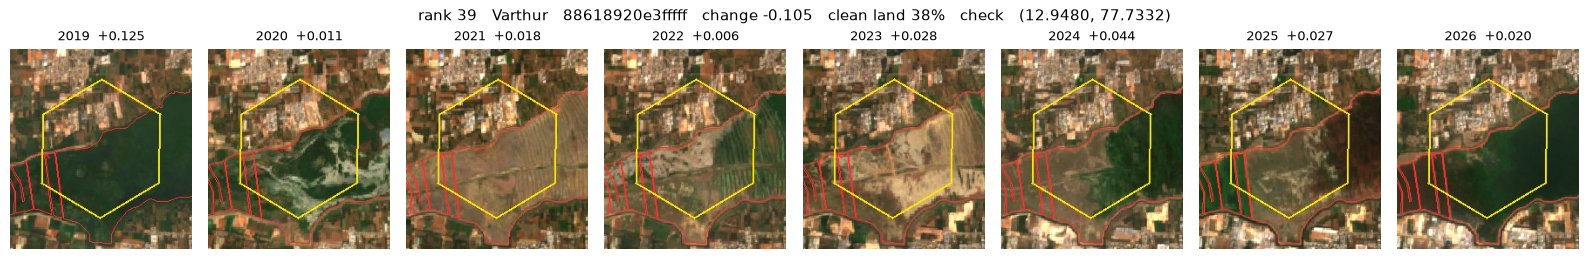

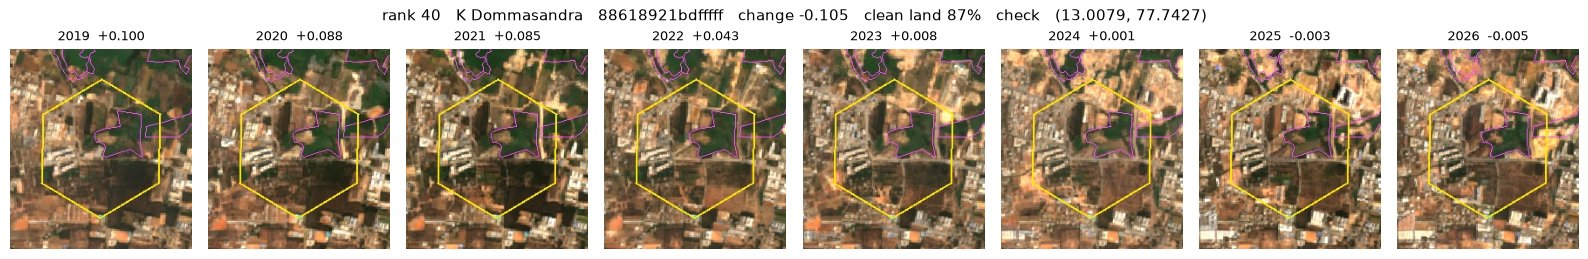

In [3]:
for hx in todo:
    geom = hex_geom(hx)
    lat, lng = h3.cell_to_latlng(hx)
    region = geom.buffer(250).bounds()
    bounds = (lng - 0.012, lat - 0.012, lng + 0.012, lat + 0.012)
    edges = [e for e in (outline(near(masked, bounds), MASK_EDGE),
                         outline(near(wetland, bounds), WETLAND_EDGE),
                         ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(geom)]), 1, 2)
                         .selfMask().visualize(palette=[HEX_EDGE])) if e is not None]
    fig, axes = plt.subplots(1, len(YEARS), figsize=(16, 2.6))
    for ax, year in zip(axes, YEARS):
        rgb = composite(year, region).visualize(bands=["B4", "B3", "B2"], min=0, max=RGB_MAX)
        for e in edges:
            rgb = rgb.blend(e)
        ax.imshow(thumb(rgb, region))
        ax.set_title(f"{year}  {norm.loc[hx, year]:+.3f}", fontsize=9)
        ax.set_axis_off()
    flag = "   check" if clean_land[hx] < CLEAN_CUTOFF else ""
    fig.suptitle(f"rank {rank[hx]}   {locality(hx)}   {hx}   change {change[hx]:+.3f}   "
                 f"clean land {clean_land[hx]:.0%}{flag}   ({lat:.4f}, {lng:.4f})", fontsize=10.5)
    plt.tight_layout(); plt.show()

---
## 3 — A verdict for every one of the 40

Written by eye from the photos: ranks 1-8 from `m2_top_photo_check.ipynb` (2026-09-23), ranks 9-40
from section 2 above. Stored in `results/m2_loss_verdicts.csv`, one row per hex with a one-line
note of what the photos show. Below: the counts, the verdicts against the `check` flag, and the hexes
that lose more than half their drop in the single step from 2019 to 2020, and which hexes
leave the top 40 if the start year is 2020 instead (`rank_from_2020` in the CSV).

In [4]:
HEADLINE = ("real loss", "real loss, wetland")

verdicts = pd.read_csv("results/m2_loss_verdicts.csv").set_index("h3")
assert list(verdicts.index) == list(losses)
print(verdicts.verdict.value_counts().to_string())
print(f"\nheadline list (real loss, on dry land or wetland): {verdicts.verdict.isin(HEADLINE).sum()} of {TOP}\n")
print(pd.crosstab(verdicts.verdict, (clean_land[losses] < CLEAN_CUTOFF).map({True: "check", False: "clean"}),
                  margins=True).to_string())

first_step = ((norm[YEARS[1]] - norm[YEARS[0]]) / change)[losses]
early = first_step[first_step > 0.5].index
print(f"\nmore than half of the drop in {YEARS[0]}->{YEARS[1]}: "
      + ", ".join(f"rank {rank[h]} ({verdicts.verdict[h]}, {first_step[h]:.0%})" for h in early))
from_2020 = verdicts.rank_from_2020
left = verdicts.index[from_2020 > TOP]
print(f"\nleave the top {TOP} with a {YEARS[1]} start: {len(left)} — "
      + ", ".join(f"rank {rank[h]} ({verdicts.verdict[h]}, now {from_2020[h]})" for h in left))
print(f"headline hexes still in the top {TOP} with a {YEARS[1]} start: "
      f"{(verdicts.verdict.isin(HEADLINE) & (from_2020 <= TOP)).sum()} of {verdicts.verdict.isin(HEADLINE).sum()}")
with pd.option_context("display.max_colwidth", 95, "display.width", 250):
    print()
    print(verdicts.set_index("rank")[["locality", "change", "verdict", "note"]].to_string())

verdict
real loss             27
doubtful               6
lake works             4
real loss, wetland     3

headline list (real loss, on dry land or wetland): 30 of 40

col_0               check  clean  All
verdict                              
doubtful                2      4    6
lake works              4      0    4
real loss               6     21   27
real loss, wetland      3      0    3
All                    15     25   40

more than half of the drop in 2019->2020: rank 28 (doubtful, 58%), rank 34 (doubtful, 53%), rank 38 (doubtful, 82%), rank 39 (lake works, 109%)

leave the top 40 with a 2020 start: 8 — rank 20 (real loss, now 72), rank 23 (real loss, now 67), rank 28 (doubtful, now 168), rank 29 (doubtful, now 95), rank 31 (doubtful, now 93), rank 34 (doubtful, now 149), rank 38 (doubtful, now 656), rank 39 (lake works, now 1807)
headline hexes still in the top 40 with a 2020 start: 28 of 30

                             locality  change             verdict                 

---
## What this shows

**30 of the 40 biggest losses are real green cover lost on land, and they can be quoted.** 27 are
vegetation or farmland cleared and built on, and 3 are the same on mapped wetland. None of the 40 is
an artefact of water: with the 25% cutoff and the mask, no hex among ranks 9-40 has more than 5% open
water in its land in any year (section 1), against 2 of the masked top 12 before the 25% cutoff.

| verdict | count | what they are |
|---|---|---|
| real loss | 27 | the Shivaram Karanth Layout (11 hexes, cleared in one go in 2024); the Whitefield-Varthur-Sarjapura side (farmland and green plots built on, mostly gradually); the STRR highway and a warehouse at Kolathuru; layouts near Gudimavu and Tagachaguppe |
| real loss, wetland | 3 | the development east of Whitefield (ranks 1 and 3) and the wetland valley at rank 11 |
| lake works | 4 | Ramapura Kere and its wetland margin (ranks 2 and 15), Chikka Banavara Lake drained and dug in 2025 (26), Varthur Lake weed clearing and desilting (39) |
| doubtful | 6 | farmland with no visible clearing, where the decline looks like a change of crops (29, 31); a drop concentrated in 2019-20 with nothing to see (28, 34, 38); the Bellandur shore, where building and lake works overlap (24) |

**The `check` flag points in the right direction but isn't a verdict.** All 4 lake-works hexes are
flagged; so are 9 real losses (3 of them on wetland) and 2 doubtful ones. Of the 25 clean hexes, 21
are real losses and 4 are doubtful, all farmland. So the flag finds lake trouble, and farmland doubt
needs the photos.

**The 2019-to-2020 step, and which verdicts depend on it.** East of 77.8°E, greenness fell from 2019
to 2020 against the city by 0.032 in one year, a third of a rank-40 loss; the middle band fell 0.007
and the west rose 0.007. Start the change in 2020 instead and 8 hexes leave the top 40: **6 of them
are 5 of the 6 doubtful hexes (all but the Bellandur shore) and the Varthur weed clearing**, and the other 2 are real
losses on the Varthur side (ranks 20 and 23, which fall to 72 and 67). So the photos and the
start-year test point at the same hexes. **28 of the 30 quotable losses stay in the top 40 either
way**; ranks 20 and 23 are real in the photos, but their place in the ranking depends on 2019, and
their notes say so. This is also why a 2019 endpoint is worth showing beside 2020 on the site.

**Editorial call on lake works (made 2026-09-27 while Aditya asked for the milestone to be finished
without check-ins; easy to reverse):** the 4 lake-works hexes stay on the map with that label, but
are left out of the headline list. They are real vegetation removal, but a lake project isn't the
development story, and quoting them would invite an easy rebuttal. The 6 doubtful hexes are left
out of the headline list too.